# Practical Session: Data Visualization with Matplotlib & Seaborn
**Dataset:** Test.csv — Monthly Sales, Expenses & Profit

---

## Setup — Import Libraries & Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('Test.csv')
print(df)
print('\nColumn types:')
print(df.dtypes)

        Month  Sales  Expenses  Profit
0     January   2000      1500     500
1    February   2500      1600     900
2       March   3000      1800    1200
3       April   2800      1700    1100
4         May   3500      2000    1500
5        June   3700      2100    1600
6        July   4000      2200    1800
7      August   4200      2300    1900
8   September   3900      2100    1800
9     October   4500      2500    2000
10   November   4700      2600    2100
11   December   5000      2800    2200

Column types:
Month         str
Sales       int64
Expenses    int64
Profit      int64
dtype: object


---
## Part 2 — Overview of Matplotlib

### Activity 1: Line Plot — Sales Trend Over the Year

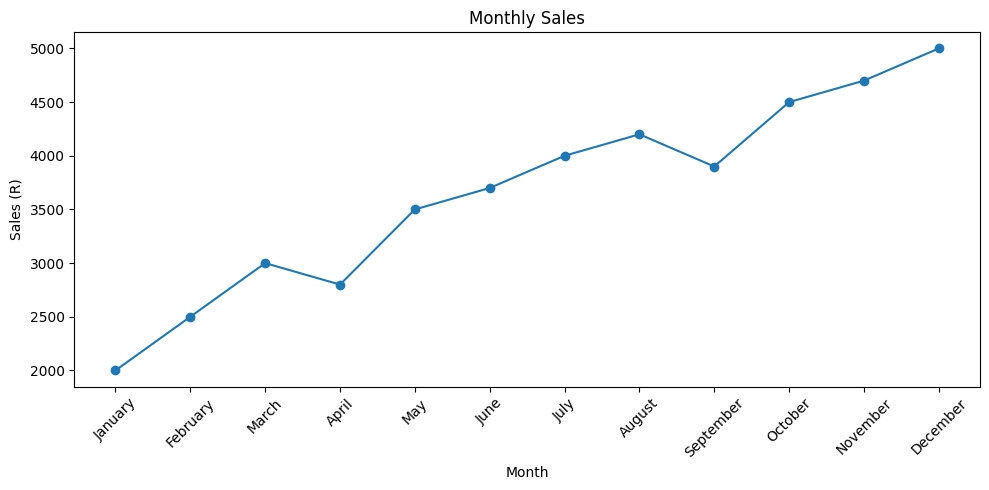

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(df['Month'], df['Sales'], marker='o')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales (R)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Activity 2: Bar Chart — Compare All Three Columns
> **Question for students:** Why is this chart hard to read? How would you fix it?

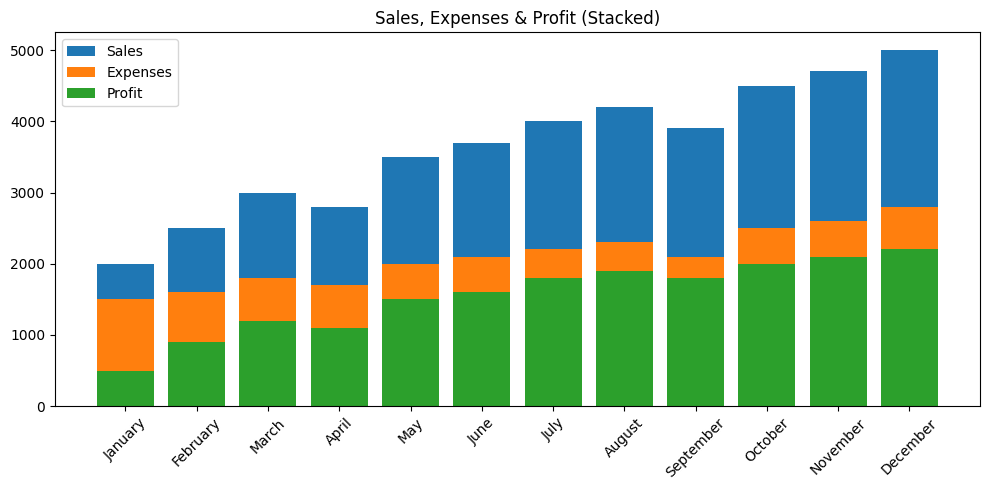

In [4]:
x = range(len(df['Month']))

plt.figure(figsize=(10, 5))
plt.bar(x, df['Sales'],    label='Sales')
plt.bar(x, df['Expenses'], label='Expenses')
plt.bar(x, df['Profit'],   label='Profit')
plt.xticks(x, df['Month'], rotation=45)
plt.legend()
plt.title('Sales, Expenses & Profit (Stacked)')
plt.tight_layout()
plt.show()

---
## Part 3 — Customizing Matplotlib Plots

### Activity 3: Grouped Bar Chart with Proper Labels

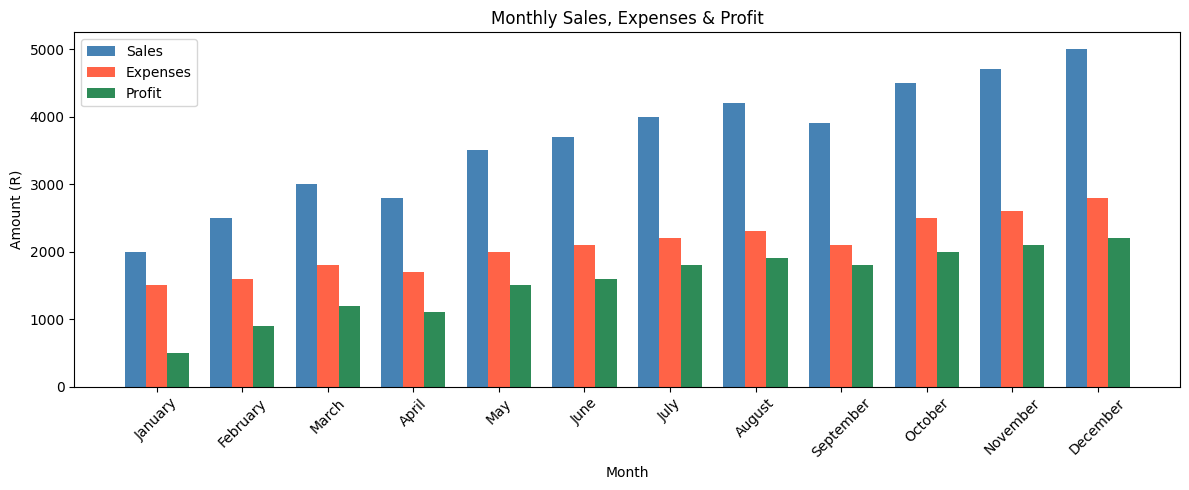

In [5]:
x = np.arange(len(df['Month']))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, df['Sales'],    width, label='Sales',    color='steelblue')
ax.bar(x,         df['Expenses'], width, label='Expenses', color='tomato')
ax.bar(x + width, df['Profit'],   width, label='Profit',   color='seagreen')

ax.set_title('Monthly Sales, Expenses & Profit')
ax.set_xlabel('Month')
ax.set_ylabel('Amount (R)')
ax.set_xticks(x)
ax.set_xticklabels(df['Month'], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### Activity 4: Subplots — One Chart Per Metric

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['Month'], df['Sales'],    color='steelblue', marker='o')
axes[0].set_title('Sales')
axes[0].set_ylabel('Amount (R)')

axes[1].plot(df['Month'], df['Expenses'], color='tomato',    marker='s')
axes[1].set_title('Expenses')

axes[2].plot(df['Month'], df['Profit'],   color='seagreen',  marker='^')
axes[2].set_title('Profit')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Financial Breakdown by Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4 — Overview of Seaborn

### Activity 5: Line Plots with Seaborn

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Month', y='Sales',    label='Sales',    marker='o')
sns.lineplot(data=df, x='Month', y='Expenses', label='Expenses', marker='s')
sns.lineplot(data=df, x='Month', y='Profit',   label='Profit',   marker='^')
plt.xticks(rotation=45)
plt.title('Financial Overview (Seaborn)')
plt.ylabel('Amount (R)')
plt.tight_layout()
plt.show()

### Activity 6: Seaborn Bar Plot Using Melted Data
> **Note:** `melt()` transforms wide data into long format — very useful for Seaborn.

In [ ]:
df_melted = df.melt(id_vars='Month', var_name='Category', value_name='Amount')
print(df_melted.head(10))

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df_melted, x='Month', y='Amount', hue='Category')
plt.xticks(rotation=45)
plt.title('Monthly Financials (Grouped Bar - Seaborn)')
plt.ylabel('Amount (R)')
plt.tight_layout()
plt.show()

---
## Part 5 — Advanced Seaborn Visualizations

### Activity 7: Heatmap — Correlations Between Financials

In [ ]:
plt.figure(figsize=(6, 4))
corr = df[['Sales', 'Expenses', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Financial Metrics')
plt.tight_layout()
plt.show()

### Activity 8: Scatter Plot — Does Higher Sales Mean Higher Profit?

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Sales', y='Profit', size='Expenses', hue='Expenses',
                sizes=(50, 300), palette='coolwarm')
plt.title('Sales vs Profit (sized by Expenses)')
plt.tight_layout()
plt.show()

---
## Part 6 — Customizing Seaborn Plots

### Activity 9: Apply a Theme and Palette
> Try changing `style` to: `darkgrid`, `ticks`, `white`  
> Try changing `palette` to: `muted`, `pastel`, `deep`, `Set1`

In [ ]:
sns.set_theme(style='whitegrid')
sns.set_palette('Set2')

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Month', y='Sales',    label='Sales',    marker='o')
sns.lineplot(data=df, x='Month', y='Expenses', label='Expenses', marker='s')
sns.lineplot(data=df, x='Month', y='Profit',   label='Profit',   marker='^')
plt.xticks(rotation=45)
plt.title('Styled Financial Overview')
plt.ylabel('Amount (R)')
plt.tight_layout()
plt.show()

---
## Wrap-up Challenge

> **Task:** Which month had the best profit margin?  
> **Profit Margin = (Profit / Sales) x 100**
>
> 1. Add a `Profit_Margin` column to the dataframe  
> 2. Plot it as a bar chart  
> 3. Highlight the highest bar in a different color

In [ ]:
# Step 1: Calculate Profit Margin
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100
print(df[['Month', 'Profit_Margin']])

In [ ]:
# Step 2 & 3: Plot with the highest bar highlighted
max_idx = df['Profit_Margin'].idxmax()
colors = ['gold' if i == max_idx else 'steelblue' for i in range(len(df))]

plt.figure(figsize=(10, 5))
bars = plt.bar(df['Month'], df['Profit_Margin'], color=colors)
plt.title('Profit Margin by Month (Highest in Gold)')
plt.xlabel('Month')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)

# Label the best month
best_month = df.loc[max_idx, 'Month']
best_value = df.loc[max_idx, 'Profit_Margin']
plt.annotate(f'Best: {best_month}\n{best_value:.1f}%',
             xy=(max_idx, best_value),
             xytext=(max_idx + 0.5, best_value + 0.5),
             fontsize=10, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred'))

plt.tight_layout()
plt.show()